# 03 - Train / validation split

**Goal:** split the cleaned training images into `train` (learning) and `val` (choosing between models), without letting near-identical images land on both sides.

**Roles of the three subsets**
- `train`: the model learns from these images.
- `val`: used to compare models and settings.
- `test`: frozen. Used once, at the very end, for the final score.

**Safety rule:** nothing in `data/` is changed. The split is only a table (`reports/splits.csv`).

The code lives in `src/split.py`.

## 1. Setup

In [1]:
import os
import sys

# If the notebook is opened from notebooks/, move to the project root.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: d:\maktab\145\tvc-clean


In [2]:
import json
from pathlib import Path

import pandas as pd

from src.utils import load_config, set_seed
from src.split import run_checks

cfg = load_config()
set_seed(cfg["seed"])
reports = Path(cfg["paths"]["reports_dir"])

splits = pd.read_csv(reports / "splits.csv")
pairs = pd.read_csv(reports / "duplicate_pairs.csv")
hashes = pd.read_csv(reports / "hashes.csv")
with open(reports / "class_to_idx.json", encoding="utf-8") as f:
    class_to_idx = json.load(f)

print("validation fraction:", cfg["data"]["val_fraction"], "| group distance:", cfg["split"]["group_distance"])

validation fraction: 0.2 | group distance: 4


## 2. How the split works

1. Start from the images marked `keep` in `reports/manifest.csv` (1,918 training images).
2. Put images whose fingerprints are close (distance <= 4) in the same **group**. One real vehicle can appear in several consecutive frames; a group keeps those frames together.
3. Use `StratifiedGroupKFold` with 5 parts and take one part (about 20%) as validation. *Group* means a group is never cut in two. *Stratified* means every class keeps about the same share.
4. Add the 400 frozen `test` images as the third subset.

## 3. Sizes

In [3]:
print(splits["subset"].value_counts().to_string())

subset
train    1534
test      400
val       384


In [4]:
table = splits.groupby(["class", "subset"]).size().unstack(fill_value=0)[["train", "val", "test"]]
table["val %"] = (100 * table["val"] / (table["train"] + table["val"])).round(1)
table

subset,train,val,test,val %
class,,,,
ambulance,175,44,50,20.1
autobus,191,48,50,20.1
kamyun,200,50,50,20.0
kamyunet,190,48,50,20.2
minibus,180,45,50,20.0
savari,200,50,50,20.0
taxi,199,49,50,19.8
vanet,199,50,50,20.1


<Axes: title={'center': 'Images per class and subset'}, xlabel='class'>

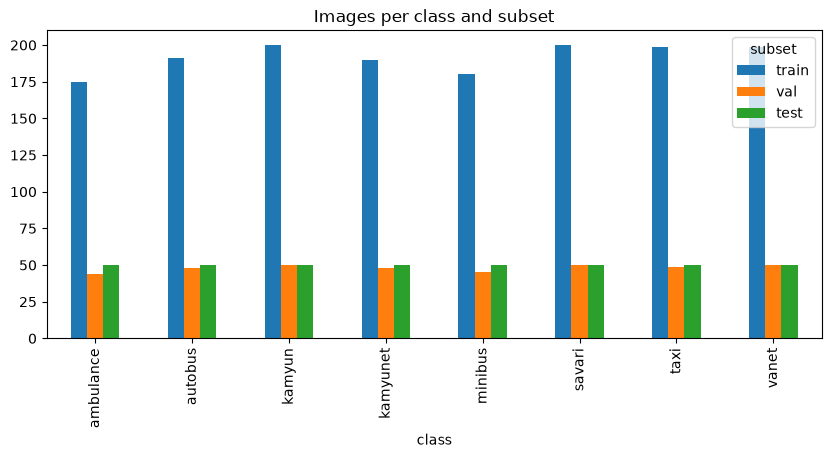

In [5]:
table[["train", "val", "test"]].plot(kind="bar", figsize=(10, 4), title="Images per class and subset")

## 4. Groups of close images

In [6]:
tv = splits[splits["subset"] != "test"]
sizes = tv.groupby("group").size()
print("groups:", len(sizes), "| groups with more than one image:", int((sizes > 1).sum()),
      "| largest group:", int(sizes.max()), "images")

multi = tv[tv["group"].isin(sizes[sizes > 1].index)].sort_values("group")
multi[["group", "class", "subset", "path"]]

groups: 1906 | groups with more than one image: 10 | largest group: 3 images


,group,class,subset,path
349,349,autobus,train,train/autobus/216551896.jpg
391,349,autobus,train,train/autobus/217780130.jpg
380,380,autobus,train,train/autobus/217091265.jpg
428,380,autobus,train,train/autobus/218625583.jpg
409,408,autobus,train,train/autobus/218092463.jpg
451,408,autobus,train,train/autobus/218952897.jpg
984,988,minibus,train,train/minibus/205808255.jpg
992,988,minibus,train,train/minibus/205930284.jpg
993,988,minibus,train,train/minibus/205936989.jpg
1055,1050,minibus,val,train/minibus/215763336.jpg


Each group appears on **one** side only. This is what the checks below prove.

## 5. Safety checks

In [7]:
run_checks(splits, pairs, hashes, cfg["split"]["group_distance"])


All checks passed. (Info: 72 weaker look-alike pairs with distance > 4 still cross train/val; most are different vehicles.)


## 6. Class numbers
The model works with numbers. They are alphabetical and are saved in `reports/class_to_idx.json`.

In [8]:
class_to_idx

{'ambulance': 0,
 'autobus': 1,
 'kamyun': 2,
 'kamyunet': 3,
 'minibus': 4,
 'savari': 5,
 'taxi': 6,
 'vanet': 7}

## 7. Findings

- **Sizes:** 1,534 `train`, 384 `val`, 400 `test` images.
- **Balance:** every class has between 19.8% and 20.2% of its images in `val`. Every class is in every subset.
- **Groups:** the 1,918 images form 1,906 groups. Only 10 groups hold more than one image (the largest has 3), so grouping changed the split only slightly, but it removes the most obvious leak.
- **Checks:** no group is split between `train` and `val`, no close pair crosses subsets, no identical file is in two subsets, and the `test` set is untouched.
- **Limitation:** 72 weaker look-alike pairs (distance 6 or 8) still cross `train` and `val`. In the pictures most of those pairs were different vehicles on the same fixed-camera background, but a few may be the same vehicle. Validation scores should therefore be read as slightly optimistic, and the final `test` score is the number to trust.

**Next step:** data loading with image transforms and augmentation, then the first small CNN as a baseline.